# Twitter Engagement Prediction — Deep Learning on Alternative Data

**Objective:** Predict whether a tweet will achieve above-median engagement (retweet count) using deep learning models trained on text content and metadata.

**Approach:** Systematic comparison of 6 architectures — from bag-of-words baselines to BERT embeddings with metadata — to quantify the value of richer text representations.

**Data:** ~15k tweets from U.S. politicians via Twitter API. Chronological 80/20 train/test split.

| # | Model | Text Representation |
|---|-------|--------------------|
| 1 | Baseline Dense | Unigram multi-hot |
| 2 | GloVe Embedding | Pre-trained GloVe 100d |
| 3 | Trained Embedding | Custom 64d |
| 4 | BERT Embedding | Pre-trained BERT 768d |
| 5 | Bigram Dense | Bigram multi-hot |
| 6 | BERT + Metadata | BERT + temporal/context features |

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split

import re

keras.utils.set_random_seed(42)

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

## 1. Data Retrieval & Preprocessing

Load tweets, filter to original content only (no retweets), clean text, and engineer metadata features.

In [ ]:
df = pd.read_csv("https://www.dropbox.com/s/53qmwe2lhotxchd/tweets_all_users.csv?dl=1")

In [ ]:
# pick one setting from the following list
user = ["AOC"] # single user
# user = ["AOC", "ewarren", "KamalaHarris", "SenTedCruz", "Sen_JoeManchin", "SenSanders", "LeaderMcConnell", "marcorubio", "LindseyGrahamSC", "GOPLeader"] # politicians
# user = ["Wendys", "pmarca", "AOC", "KimKardashian", "Nike", "NateSilver538", "KingJames", "TheEllenShow", "katyperry"] # diverse
title = "single_user" # "politicians" "diverse"

In [ ]:
df = df.loc[df.screen_name.isin(user)]

In [ ]:
# We only want to include original tweets, i.e. no retweets
df = df.loc[(~df.retweeted) & (~df.full_text.str.contains('RT @'))]

In [ ]:
def preprocess_text(sen):
    # Remove URLs
    sentence = re.sub(r'http\S+', '', sen)

    # Remove referring to another user using "@..."
    sentence = re.sub(r'@\S+', '', sentence)

    # Remove punctuations and numbers
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)

    # Single character removal
    sentence = re.sub(r"\s[a-zA-Z]\s+", ' ', sentence)

    # Removing multiple spaces
    sentence = re.sub(r'\s+', ' ', sentence)

    # LowerCase
    sentence = sentence.lower()

    return sentence

In [ ]:
X = []
sentences = list(df.full_text)
for sen in sentences:
    X.append(preprocess_text(sen))

df['full_text_new'] = X

X = []
sentences = list(df.full_text)
for sen in sentences:
    X.append(preprocess_text(sen))
df['full_text_new'] = X

### Feature Engineering

In [ ]:
df['created_at_new'] = pd.to_datetime(df['created_at'], format="%Y-%m-%d ")

In [ ]:
# We assign numbers from 1-7 for the weekday the tweet was posted
df['weekday'] = df['created_at_new'].apply(lambda x: x.day_name())
def f(row):
  if row['weekday'] == 'Monday':
    val = 1
  elif row['weekday'] == 'Tuesday':
    val = 2
  elif row['weekday'] == 'Wednesday':
    val = 3
  elif row['weekday'] == 'Thursday':
    val = 4
  elif row['weekday'] == 'Friday':
    val = 5
  elif row['weekday'] == 'Saturday':
    val = 6
  else:
      val = 7
  return val

#create new column 'Good' using the function above
df['weekday_num'] = df.apply(f, axis=1)

In [ ]:
# convert is quote status true false to integer
df.is_quote_status = df.is_quote_status*1

In [ ]:
# define if tweet was posted in reply to another tweet
df[['in_reply']] = df[['in_reply_to_screen_name']].where(df[['in_reply_to_screen_name']].isnull(), 1).fillna(0).astype(int)
df[['in_reply_to_screen_name','in_reply']]

,in_reply_to_screen_name,in_reply
1,AOC,1
2,NaN,0
3,NaN,0
5,NaN,0
6,DaveyDigest,1
...,...,...
42457,NaN,0
42458,NaN,0
42459,NaN,0
42460,NaN,0


In [ ]:
# We assign the hour of the day (between 0-24) when the tweet was posted
df['time_of_day'] = df['created_at_new'].apply(lambda x: x.time().hour)

### Train/Test Split

Chronological split — most recent 20% as test set. Target: above/below user's median retweet count.

In [ ]:
# We keep the chronological order of the tweets and use the latest 20% of the tweets as our validation set
df = df.sort_index(axis=0,ascending=False) # change rows from old to new

train_medians = []
test_medians = []
train_df = pd.DataFrame()
test_df = pd.DataFrame()
y_train_retweets = pd.Series()
y_test_retweets = pd.Series()
for usr in user:
  df_user = df.loc[df.screen_name==usr]
  X = df_user
  y = df_user['retweet_count']
  usr_train_df, usr_test_df, usr_y_train_retweets, usr_y_test_retweets = train_test_split(X, y, test_size=0.20, shuffle=False)
  train_df = train_df.append(usr_train_df)
  test_df = test_df.append(usr_test_df)
  y_train_retweets = y_train_retweets.append(usr_y_train_retweets)
  y_test_retweets = y_test_retweets.append(usr_y_test_retweets)
  median = [usr_y_train_retweets.median()] * len(usr_y_train_retweets)
  train_medians.extend(median)
  median = [usr_y_train_retweets.median()] * len(usr_y_test_retweets)
  test_medians.extend(median)

train_df['median'] = train_medians
test_df['median'] = test_medians
# y_train_retweets['median'] = train_medians
# y_test_retweets['median'] = test_medians

print(f"""
Train samples: {train_df.shape[0]}
Test samples: {test_df.shape[0]}
"""
)



Train samples: 14981
Test samples: 3748



/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:8: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:9: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  if __name__ == '__main__':


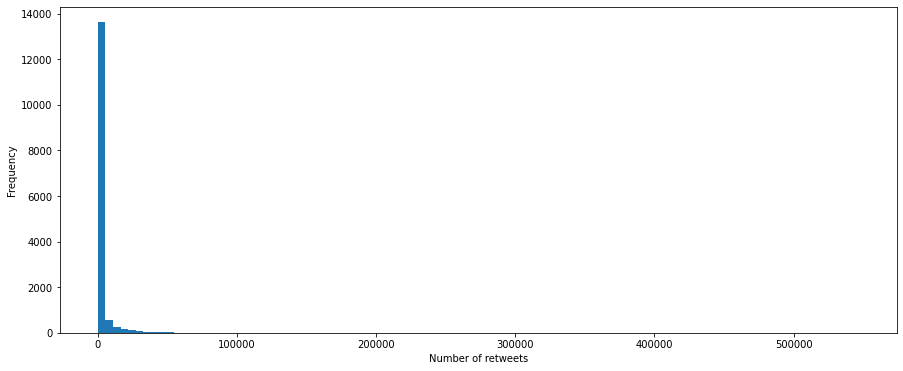

In [ ]:
# Our target variable is based on the distribution of number of retweets in the training sample.
y_train_retweets.plot.hist(bins=100, figsize=(15,6))
plt.xlabel('Number of retweets')
# plt.axvline(median, color='r', linestyle='--')
plt.savefig('frequency.png')

In [ ]:
y_train = pd.Series(np.where(y_train_retweets.values >= train_df['median'].values, "High", "Low"))
y_test = pd.Series(np.where(y_test_retweets.values >= test_df['median'].values, "High", "Low"))

In [ ]:
# Inspect the distribution of variable engagement_score
print(y_train.value_counts()) # should be perfectly balanced by our definition
print(y_test.value_counts()) # might be biased due to changing user engagement in validation set

High    8250
Low     6731
dtype: int64
Low     1971
High    1777
dtype: int64


In [ ]:
# X1 contains the actual tweet content
X1_train = train_df['full_text_new']
X1_test = test_df['full_text_new']

In [ ]:
# X2 contains multiple variables on Meta information: We use the weekday (1-7) and the time of the day (0-24)
X2_train = train_df[['weekday_num', 'time_of_day', 'is_quote_status', 'in_reply']].values
X2_test = test_df[['weekday_num', 'time_of_day', 'is_quote_status', 'in_reply']].values

In [ ]:
# We turn our target variable into a dummy variable
y_train = pd.get_dummies(y_train).to_numpy()
y_test = pd.get_dummies(y_test).to_numpy()
print(y_train[0:10])

[[1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]]


---
## 2. Model 1 — Unigram Multi-Hot Baseline

Simplest bag-of-words: each tweet represented as a binary vector over the vocabulary.

In [ ]:
# Set the maximum number of tokens
max_tokens = 10000
max_length = int(np.quantile(X1_train.str.len(), 0.9, axis=0)) # length is smaller for 90% of all tweets

In [ ]:
# Build the text vectorization layer
text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="multi_hot",
    ngrams=1  # we will use unigrams
)
text_vectorization.adapt(X1_train)


In [ ]:
# We vectorize our input
input_vocab = text_vectorization.vocabulary_size()
X1_train_vec = text_vectorization(X1_train)
X1_test_vec = text_vectorization(X1_test)

In [ ]:
# Build a small baseline model with one hidden layer
inputs = keras.Input(shape=(input_vocab, ))
x = keras.layers.Dense(8, activation="relu")(inputs)
outputs = keras.layers.Dense(2, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.summary()


Model: "model_536"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1047 (InputLayer)     [(None, 10000)]           0         
                                                                 
 dense_97 (Dense)            (None, 8)                 80008     
                                                                 
 dense_98 (Dense)            (None, 2)                 18        
                                                                 
Total params: 80,026
Trainable params: 80,026
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# Compile model using Adam
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])
# Fit model on the training data with 10 epochs and batch size of 32
history = model.fit(x=X1_train_vec, y=y_train,
          validation_data=(X1_test_vec, y_test),
          epochs=30,
          batch_size=32)

Epoch 1/30
469/469 [==============================] - 2s 4ms/step - loss: 0.6005 - accuracy: 0.6482 - val_loss: 0.6290 - val_accuracy: 0.6198
Epoch 2/30
469/469 [==============================] - 16s 33ms/step - loss: 0.4707 - accuracy: 0.7646 - val_loss: 0.6513 - val_accuracy: 0.6321
Epoch 3/30
469/469 [==============================] - 6s 13ms/step - loss: 0.3962 - accuracy: 0.8112 - val_loss: 0.7275 - val_accuracy: 0.6107
Epoch 4/30
469/469 [==============================] - 5s 10ms/step - loss: 0.3442 - accuracy: 0.8382 - val_loss: 0.7615 - val_accuracy: 0.6278
Epoch 5/30
469/469 [==============================] - 10s 21ms/step - loss: 0.3038 - accuracy: 0.8575 - val_loss: 0.8245 - val_accuracy: 0.6246
Epoch 6/30
469/469 [==============================] - 6s 13ms/step - loss: 0.2730 - accuracy: 0.8712 - val_loss: 0.8962 - val_accuracy: 0.6241
Epoch 7/30
469/469 [==============================] - 10s 20ms/step - loss: 0.2459 - accuracy: 0.8867 - val_loss: 0.9812 - val_accuracy: 0.62

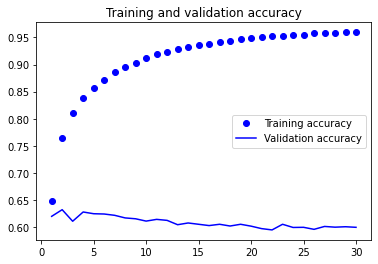

In [ ]:
plot_learning_curve(history)

In [ ]:
# Accuracy on test data
score = model.evaluate(x=X1_test_vec, y=y_test)
print("Test Score:", score[0])
print("Test Accuracy:", score[1])
res = [["1 Baseline model using unigrams and multi-hot word-vectors", score[0], score[1]]]

118/118 [==============================] - 0s 3ms/step - loss: 3.2137 - accuracy: 0.5995
Test Score: 3.2137348651885986
Test Accuracy: 0.5995197296142578


---
## 3. Model 2 — GloVe Pre-trained Embeddings

Transfer learning with pre-trained GloVe 100d word vectors as a frozen embedding layer.

In [ ]:
embedding_dim = 100
path_to_glove_file = f"glove.6B.{embedding_dim}d.txt"

embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors.")

Found 400000 word vectors.


In [ ]:
text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=max_length,
)

text_vectorization.adapt(X1_train)

In [ ]:
# We vectorize our input
input_vocab = text_vectorization.vocabulary_size()
X1_train_vec = text_vectorization(X1_train)
X1_test_vec = text_vectorization(X1_test)

In [ ]:
vocabulary = text_vectorization.get_vocabulary()
word_index = dict(zip(vocabulary, range(len(vocabulary))))

counter = 0
embedding_matrix = np.zeros((max_tokens, embedding_dim))
for word, i in word_index.items():
    if i < max_tokens:
        embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
    else:
        counter += 1

In [ ]:
# Creation of the embedding layer. We keep the training process frozen for this layer.
embedding_layer = keras.layers.Embedding(
    max_tokens,
    embedding_dim,
    embeddings_initializer= keras.initializers.Constant(embedding_matrix),
    trainable=False,
)

In [ ]:
# Build a small baseline model with one hidden layer

inputs = keras.Input(shape=(max_length,))
embedded = embedding_layer(inputs)
embedded = keras.layers.GlobalAveragePooling1D()(embedded) # 100-element vector
x = keras.layers.Dense(16)(embedded)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(2, activation="softmax")(x)

model = keras.Model(inputs, outputs)


In [ ]:
# Compile model using Adam
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])
# Fit model on the training data with 10 epochs and batch size of 32
history = model.fit(x=X1_train_vec, y=y_train,
          validation_data=(X1_test_vec, y_test),
          epochs=30,
          batch_size=32)

Epoch 1/30
469/469 [==============================] - 24s 50ms/step - loss: 0.6839 - accuracy: 0.5497 - val_loss: 0.7022 - val_accuracy: 0.4728
Epoch 2/30
469/469 [==============================] - 6s 12ms/step - loss: 0.6742 - accuracy: 0.5550 - val_loss: 0.6912 - val_accuracy: 0.4883
Epoch 3/30
469/469 [==============================] - 8s 18ms/step - loss: 0.6650 - accuracy: 0.5677 - val_loss: 0.7238 - val_accuracy: 0.4664
Epoch 4/30
469/469 [==============================] - 12s 25ms/step - loss: 0.6575 - accuracy: 0.5709 - val_loss: 0.6954 - val_accuracy: 0.5085
Epoch 5/30
469/469 [==============================] - 6s 13ms/step - loss: 0.6538 - accuracy: 0.5753 - val_loss: 0.6825 - val_accuracy: 0.5390
Epoch 6/30
469/469 [==============================] - 4s 8ms/step - loss: 0.6508 - accuracy: 0.5757 - val_loss: 0.6825 - val_accuracy: 0.5432
Epoch 7/30
469/469 [==============================] - 6s 13ms/step - loss: 0.6493 - accuracy: 0.5803 - val_loss: 0.6839 - val_accuracy: 0.538

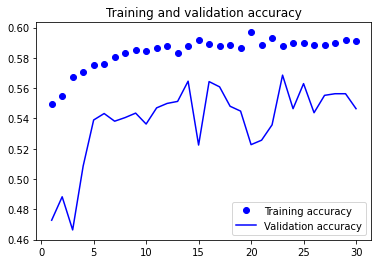

In [ ]:
plot_learning_curve(history)

In [ ]:
# Accuracy on test data
score = model.evaluate(x=X1_test_vec, y=y_test)
print("Test Score:", score[0])
print("Test Accuracy:", score[1])
res.append(["2 Baseline model using unigrams and Glove word embeddings", score[0], score[1]])

118/118 [==============================] - 0s 2ms/step - loss: 0.6805 - accuracy: 0.5464
Test Score: 0.680503249168396
Test Accuracy: 0.5464247465133667


---
## 4. Model 3 — Trained Embeddings

Learn embeddings from scratch on the tweet corpus (64 dimensions, trainable).

In [ ]:
# We can also use our own embedding layer:
inputs = keras.Input(shape=(max_length,))

embedded = keras.layers.Embedding(input_dim=max_tokens,
                                  output_dim=64, )(inputs)

embedded = keras.layers.GlobalAveragePooling1D()(embedded)

x = keras.layers.Dense(32)(embedded)

x = keras.layers.Dropout(0.5)(x)

outputs = keras.layers.Dense(2, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "model_538"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1049 (InputLayer)     [(None, 249)]             0         
                                                                 
 embedding_10 (Embedding)    (None, 249, 64)           640000    
                                                                 
 global_average_pooling1d_10  (None, 64)               0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dense_101 (Dense)           (None, 32)                2080      
                                                                 
 dropout_21 (Dropout)        (None, 32)                0         
                                                                 
 dense_102 (Dense)           (None, 2)                 66        
                                                         

In [ ]:
# Compile model using Adam
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])
# Fit model on the training data with 10 epochs and batch size of 32
history = model.fit(x=X1_train_vec, y=y_train,
          validation_data=(X1_test_vec, y_test),
          epochs=30,
          batch_size=32)

Epoch 1/30
469/469 [==============================] - 9s 18ms/step - loss: 0.6776 - accuracy: 0.5606 - val_loss: 0.6798 - val_accuracy: 0.4987
Epoch 2/30
469/469 [==============================] - 8s 16ms/step - loss: 0.6002 - accuracy: 0.6468 - val_loss: 0.6362 - val_accuracy: 0.6134
Epoch 3/30
469/469 [==============================] - 7s 14ms/step - loss: 0.5154 - accuracy: 0.7302 - val_loss: 0.6957 - val_accuracy: 0.5824
Epoch 4/30
469/469 [==============================] - 10s 22ms/step - loss: 0.4572 - accuracy: 0.7640 - val_loss: 0.6830 - val_accuracy: 0.6054
Epoch 5/30
469/469 [==============================] - 7s 14ms/step - loss: 0.4164 - accuracy: 0.7925 - val_loss: 0.7182 - val_accuracy: 0.6073
Epoch 6/30
469/469 [==============================] - 9s 15ms/step - loss: 0.3847 - accuracy: 0.8112 - val_loss: 0.8039 - val_accuracy: 0.6017
Epoch 7/30
469/469 [==============================] - 13s 28ms/step - loss: 0.3591 - accuracy: 0.8236 - val_loss: 0.7770 - val_accuracy: 0.63

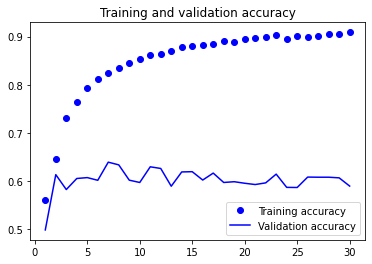

In [ ]:
plot_learning_curve(history)

In [ ]:
# Accuracy on test data
score = model.evaluate(x=X1_test_vec, y=y_test)
print("Test Score:", score[0])
print("Test Accuracy:", score[1])
res.append(["3 Baseline model using unigrams and our own embeddings", score[0], score[1]])

118/118 [==============================] - 5s 39ms/step - loss: 1.9089 - accuracy: 0.5896
Test Score: 1.9089388847351074
Test Accuracy: 0.5896478295326233


---
## 5. Model 4 — BERT Embeddings

Pre-trained BERT (12-layer, 768d) as a frozen feature extractor. Contextual representations capture meaning beyond individual words.

In [ ]:
!pip install -q -U tensorflow-text ## install the package for NLP tasks in tensorflow

In [ ]:
import tensorflow_hub as hub
import tensorflow_text

bert_preprocess = 'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3'

bert_layers = 12
bert_units = 768
bert_heads = 12

bert_encoder = f'https://tfhub.dev/tensorflow/bert_en_uncased_L-{bert_layers}_H-{bert_units}_A-{bert_heads}/4'

In [ ]:
preprocessor = hub.load(bert_preprocess)
encoder = hub.KerasLayer(bert_encoder, trainable=False)

def bert_textvect(x):
  input = keras.layers.Input(shape=(), dtype=tf.string)
  tokenized_input = hub.KerasLayer(preprocessor.tokenize)(input)
  bert_pack_inputs = hub.KerasLayer(preprocessor.bert_pack_inputs, arguments=dict(seq_length=max_length))
  output = bert_pack_inputs([tokenized_input])
  model = keras.Model(input, output)
  result = model.predict(x)
  return result

def bert_features(x):
  inputs = dict(
    input_word_ids=keras.layers.Input(shape=(max_length,), dtype=tf.int32),
    input_mask=keras.layers.Input(shape=(max_length,), dtype=tf.int32),
    input_type_ids=keras.layers.Input(shape=(max_length,), dtype=tf.int32),
  )

  output = encoder(inputs)['sequence_output'][:, 0, :]
  model = keras.Model(inputs, output)
  return model.predict(x)


In [ ]:
X_bert_train = bert_textvect(X1_train)
X_bert_test = bert_textvect(X1_test)

features_train = bert_features(X_bert_train)
features_test = bert_features(X_bert_test)

In [ ]:
hidden_units = 64

# Input
input = keras.Input(shape=(bert_units, ))

# Classification Head
x = keras.layers.Dense(hidden_units)(input)
x = keras.layers.Dense(hidden_units)(x)
#x = keras.layers.Dropout(0.1)(x)
output = keras.layers.Dense(2, activation='softmax')(x)

# Model
model = keras.Model(input, output)

model.summary()

Model: "model_543"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1058 (InputLayer)     [(None, 768)]             0         
                                                                 
 dense_103 (Dense)           (None, 64)                49216     
                                                                 
 dense_104 (Dense)           (None, 64)                4160      
                                                                 
 dense_105 (Dense)           (None, 2)                 130       
                                                                 
Total params: 53,506
Trainable params: 53,506
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# Compile model using Adam
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])
# Fit model on the training data with 10 epochs and batch size of 32
history = model.fit(x=features_train, y=y_train,
          validation_data=(features_test, y_test),
          epochs=30,
          batch_size=32)

Epoch 1/20
469/469 [==============================] - 18s 37ms/step - loss: 0.6370 - accuracy: 0.6169 - val_loss: 0.6659 - val_accuracy: 0.5918
Epoch 2/20
469/469 [==============================] - 3s 7ms/step - loss: 0.6040 - accuracy: 0.6512 - val_loss: 0.6626 - val_accuracy: 0.5990
Epoch 3/20
469/469 [==============================] - 7s 16ms/step - loss: 0.5953 - accuracy: 0.6585 - val_loss: 0.6812 - val_accuracy: 0.5939
Epoch 4/20
469/469 [==============================] - 4s 9ms/step - loss: 0.5912 - accuracy: 0.6643 - val_loss: 0.6524 - val_accuracy: 0.6222
Epoch 5/20
469/469 [==============================] - 10s 21ms/step - loss: 0.5856 - accuracy: 0.6654 - val_loss: 0.6532 - val_accuracy: 0.6158
Epoch 6/20
469/469 [==============================] - 4s 7ms/step - loss: 0.5835 - accuracy: 0.6658 - val_loss: 0.7014 - val_accuracy: 0.5694
Epoch 7/20
469/469 [==============================] - 4s 8ms/step - loss: 0.5810 - accuracy: 0.6674 - val_loss: 0.6516 - val_accuracy: 0.6078
E

In [ ]:
# Accuracy on test data
score = model.evaluate(x=features_test,y=y_test)
print("Test Score:", score[0])
print("Test Accuracy:", score[1])
res.append(["4 Baseline model using unigrams and BIRT embeddings", score[0], score[1]])

118/118 [==============================] - 0s 3ms/step - loss: 0.6665 - accuracy: 0.5993
Test Score: 0.6665133237838745
Test Accuracy: 0.5992529392242432


---
## 6. Model 5 — Bigram Multi-Hot

Capture word-pair patterns using multi-hot encoding over the top 10k bigrams.

In [ ]:
# Text Vectorization layer using bigrams
text_vectorization = keras.layers.TextVectorization(
    ngrams=2,
    max_tokens=max_tokens,
    output_mode="multi_hot",
)
text_vectorization.adapt(X1_train)

In [ ]:
X1_train_vec = text_vectorization(X1_train)
X1_test_vec = text_vectorization(X1_test)

In [ ]:
inputs = keras.Input(shape=(max_tokens,))
x = keras.layers.Dense(8, activation="relu")(inputs)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(2, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "model_544"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1059 (InputLayer)     [(None, 10000)]           0         
                                                                 
 dense_106 (Dense)           (None, 8)                 80008     
                                                                 
 dropout_22 (Dropout)        (None, 8)                 0         
                                                                 
 dense_107 (Dense)           (None, 2)                 18        
                                                                 
Total params: 80,026
Trainable params: 80,026
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# Compile model using Adam
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])
# Fit model on the training data with 10 epochs and batch size of 32
history = model.fit(x=X1_train_vec, y=y_train,
          validation_data=(X1_test_vec, y_test),
          epochs=30,
          batch_size=32)

Epoch 1/30
469/469 [==============================] - 19s 24ms/step - loss: 0.6231 - accuracy: 0.6107 - val_loss: 0.6334 - val_accuracy: 0.6083
Epoch 2/30
469/469 [==============================] - 4s 9ms/step - loss: 0.5395 - accuracy: 0.7150 - val_loss: 0.6232 - val_accuracy: 0.6273
Epoch 3/30
469/469 [==============================] - 4s 8ms/step - loss: 0.4800 - accuracy: 0.7641 - val_loss: 0.6556 - val_accuracy: 0.6201
Epoch 4/30
469/469 [==============================] - 10s 22ms/step - loss: 0.4373 - accuracy: 0.7909 - val_loss: 0.6508 - val_accuracy: 0.6291
Epoch 5/30
469/469 [==============================] - 7s 15ms/step - loss: 0.4006 - accuracy: 0.8117 - val_loss: 0.6911 - val_accuracy: 0.6337
Epoch 6/30
469/469 [==============================] - 6s 13ms/step - loss: 0.3778 - accuracy: 0.8252 - val_loss: 0.7164 - val_accuracy: 0.6265
Epoch 7/30
469/469 [==============================] - 6s 12ms/step - loss: 0.3532 - accuracy: 0.8406 - val_loss: 0.7736 - val_accuracy: 0.6302

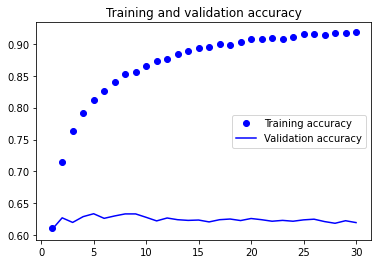

In [ ]:
plot_learning_curve(history)

In [ ]:
# Accuracy on test data
score = model.evaluate(x=X1_test_vec, y=y_test)
print("Test Score:", score[0])
print("Test Accuracy:", score[1])
res.append(["5 Baseline model using biagrams", score[0], score[1]])

118/118 [==============================] - 0s 3ms/step - loss: 1.9170 - accuracy: 0.6198
Test Score: 1.9170258045196533
Test Accuracy: 0.6197972297668457


---
## 7. Model 6 — BERT + Metadata (Concatenated)

Best model: BERT text embeddings concatenated with metadata features (weekday, hour, quote status, reply status) in a multi-input architecture.

In [ ]:
input_1 =  keras.Input(shape=(bert_units, ))
input_2 = keras.layers.Input(shape=(4,)) # the parameters (=4 atm) = # of meta variables

# Classification Head
embedded = keras.layers.Dense(hidden_units)(input_1)
embedded = keras.layers.Dense(hidden_units)(embedded)

# Now we create the second submodel that accepts input from the second input layer:
dense_layer_1 = keras.layers.Dense(8, activation='relu')(input_2)
x = keras.layers.Dropout(0.5)(dense_layer_1)
#dense_layer_2 = keras.layers.Dense(8, activation='relu')(dense_layer_1)

# As a next step we merge the two layers together
concat_layer = keras.layers.Concatenate()([embedded, x])
dense_layer_3 = keras.layers.Dense(10, activation='relu')(concat_layer)
output = keras.layers.Dense(2, activation='softmax')(dense_layer_3)

model = keras.models.Model(inputs=[input_1, input_2], outputs=output)

model.summary()

Model: "model_545"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1060 (InputLayer)        [(None, 768)]        0           []                               
                                                                                                  
 input_1061 (InputLayer)        [(None, 4)]          0           []                               
                                                                                                  
 dense_108 (Dense)              (None, 64)           49216       ['input_1060[0][0]']             
                                                                                                  
 dense_110 (Dense)              (None, 8)            40          ['input_1061[0][0]']             
                                                                                          

In [ ]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])
# Fit model on the training data with 10 epochs and batch size of 32
history = model.fit(x=[features_train, X2_train], y=y_train,
          validation_data=([features_test, X2_test], y_test),
          epochs=30,
          batch_size=32)

Epoch 1/30
469/469 [==============================] - 17s 19ms/step - loss: 0.6656 - accuracy: 0.5982 - val_loss: 0.6809 - val_accuracy: 0.6142
Epoch 2/30
469/469 [==============================] - 9s 18ms/step - loss: 0.6073 - accuracy: 0.6500 - val_loss: 0.6578 - val_accuracy: 0.6158
Epoch 3/30
469/469 [==============================] - 9s 18ms/step - loss: 0.5743 - accuracy: 0.6791 - val_loss: 0.6670 - val_accuracy: 0.6097
Epoch 4/30
469/469 [==============================] - 9s 20ms/step - loss: 0.5509 - accuracy: 0.6962 - val_loss: 0.6327 - val_accuracy: 0.6403
Epoch 5/30
469/469 [==============================] - 6s 13ms/step - loss: 0.5377 - accuracy: 0.7059 - val_loss: 0.6108 - val_accuracy: 0.6465
Epoch 6/30
469/469 [==============================] - 6s 13ms/step - loss: 0.5308 - accuracy: 0.7104 - val_loss: 0.6499 - val_accuracy: 0.6174
Epoch 7/30
469/469 [==============================] - 7s 14ms/step - loss: 0.5252 - accuracy: 0.7116 - val_loss: 0.6198 - val_accuracy: 0.633

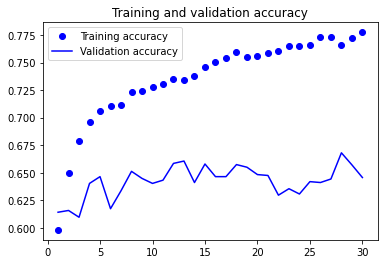

In [ ]:
plot_learning_curve(history)

In [ ]:
score = model.evaluate(x=[features_test, X2_test], y=y_test, verbose=1)

print("Test Score:", score[0])
print("Test Accuracy:", score[1])

res.append(["6 Concatenated model with meta information", score[0], score[1]])

118/118 [==============================] - 0s 3ms/step - loss: 0.6947 - accuracy: 0.6457
Test Score: 0.6946893930435181
Test Accuracy: 0.6456776857376099


---
## 8. Results Comparison

In [ ]:
res = pd.DataFrame(res, columns=["Name", "Test Score", "Test Accuracy"])
res.to_csv(title + ".csv")
res

,Name,Test Score,Test Accuracy
0,1 Baseline model using unigrams and multi-hot ...,3.213735,0.599520
1,2 Baseline model using unigrams and Glove word...,0.680503,0.546425
2,3 Baseline model using unigrams and our own em...,1.908939,0.589648
3,4 Baseline model using unigrams and BIRT embed...,0.666513,0.599253
4,5 Baseline model using biagrams,1.917026,0.619797
5,6 Concatenated model with meta information,0.694689,0.645678


In [ ]:
res

,Name,Test Score,Test Accuracy
0,1 Baseline model using unigrams and multi-hot ...,3.213735,0.599520
1,2 Baseline model using unigrams and Glove word...,0.680503,0.546425
2,3 Baseline model using unigrams and our own em...,1.908939,0.589648
3,4 Baseline model using unigrams and BIRT embed...,0.666513,0.599253
4,5 Baseline model using biagrams,1.917026,0.619797
5,6 Concatenated model with meta information,0.694689,0.645678


---
## 9. Application — Predict Engagement for New Tweets

Using the best model (BERT + Metadata) to predict engagement for arbitrary tweets.

In [ ]:
def predict_engagement(tweet, weekday, hour, quote, replied):
  # when using not BERT
  # raw_text_data = tf.convert_to_tensor([[tweet],])
  # vect_data = text_vectorization(raw_text_data)
  #
  tweet = preprocess_text(tweet)
  a = bert_textvect([tweet])
  vect_data = bert_features(a)

  meta_data = tf.convert_to_tensor([[weekday, hour, quote, replied]])

  predictions = model.predict([vect_data, meta_data])
  predictions
  # print(f"{float(predictions[0,0] * 100):.2f} % Low Engagement")
  print(f"{float(predictions[0,1] * 100):.2f} % High Engagement")

In [ ]:
predict_engagement("Free Melania Trump!", 1, 12, 0, 0) # AOC
predict_engagement("I want to stand by something, but by example.", 1, 12, 0, 0) # politican
predict_engagement("You're not alone in this struggle!", 1, 12, 0, 0) # diverse
predict_engagement("Thank you, Alyssa", 1, 12, 0, 0) # diverse
predict_engagement("Merry Christmas", 1, 12, 0, 0)
predict_engagement("I am an elephant", 1, 12, 0, 0)
predict_engagement("Peace in Ukraine", 1, 12, 0, 0)

8.72 % High Engagement
5.20 % High Engagement
45.35 % High Engagement
39.37 % High Engagement
10.60 % High Engagement
27.50 % High Engagement
0.01 % High Engagement


In [ ]:
# Influence of
predict_engagement("Peace in Ukraine", 1, 12, 0, 0)
predict_engagement("If only Elon paid taxes as often as he tweets", 1, 12, 0, 0)
predict_engagement("Peace in Ukraine", 1, 12, 1, 0)
predict_engagement("If only Elon paid taxes as often as he tweets", 1, 12, 1, 0)
predict_engagement("Peace in Ukraine", 1, 12, 0, 1)
predict_engagement("If only Elon paid taxes as often as he tweets", 1, 12, 0, 1)

0.01 % High Engagement
24.77 % High Engagement
0.03 % High Engagement
26.70 % High Engagement
0.23 % High Engagement
68.54 % High Engagement
